In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 读取CSV文件（使用分号作为分隔符，逗号作为千位分隔符）
df = pd.read_csv('../Data/Day-ahead_prices_201901010000_202603240000_Quarterhour.csv', 
                  sep=';', 
                  decimal=',')

# 查看前几行
print(df.head())

             Start date              End date  \
0  Jan 1, 2019 12:00 AM  Jan 1, 2019 12:15 AM   
1  Jan 1, 2019 12:15 AM  Jan 1, 2019 12:30 AM   
2  Jan 1, 2019 12:30 AM  Jan 1, 2019 12:45 AM   
3  Jan 1, 2019 12:45 AM   Jan 1, 2019 1:00 AM   
4   Jan 1, 2019 1:00 AM   Jan 1, 2019 1:15 AM   

  Germany/Luxembourg [€/MWh] Original resolutions  \
0                                           28.32   
1                                           28.32   
2                                           28.32   
3                                           28.32   
4                                           10.07   

  ∅ DE/LU neighbours [€/MWh] Original resolutions  \
0                                               -   
1                                               -   
2                                               -   
3                                               -   
4                                               -   

  Belgium [€/MWh] Original resolutions Denmark 1 [€/MWh] Original r

In [4]:
print(f"\n数据形状: {df.shape}")


数据形状: (253344, 19)


In [5]:
print(f"\n列名: {df.columns.tolist()}")


列名: ['Start date', 'End date', 'Germany/Luxembourg [€/MWh] Original resolutions', '∅ DE/LU neighbours [€/MWh] Original resolutions', 'Belgium [€/MWh] Original resolutions', 'Denmark 1 [€/MWh] Original resolutions', 'Denmark 2 [€/MWh] Original resolutions', 'France [€/MWh] Original resolutions', 'Netherlands [€/MWh] Original resolutions', 'Norway 2 [€/MWh] Original resolutions', 'Austria [€/MWh] Original resolutions', 'Poland [€/MWh] Original resolutions', 'Sweden 4 [€/MWh] Original resolutions', 'Switzerland [€/MWh] Original resolutions', 'Czech Republic [€/MWh] Original resolutions', 'DE/AT/LU [€/MWh] Original resolutions', 'Northern Italy [€/MWh] Original resolutions', 'Slovenia [€/MWh] Original resolutions', 'Hungary [€/MWh] Original resolutions']


In [6]:
print(f"\n数据类型:\n{df.dtypes}")


数据类型:
Start date                                         str
End date                                           str
Germany/Luxembourg [€/MWh] Original resolutions    str
∅ DE/LU neighbours [€/MWh] Original resolutions    str
Belgium [€/MWh] Original resolutions               str
Denmark 1 [€/MWh] Original resolutions             str
Denmark 2 [€/MWh] Original resolutions             str
France [€/MWh] Original resolutions                str
Netherlands [€/MWh] Original resolutions           str
Norway 2 [€/MWh] Original resolutions              str
Austria [€/MWh] Original resolutions               str
Poland [€/MWh] Original resolutions                str
Sweden 4 [€/MWh] Original resolutions              str
Switzerland [€/MWh] Original resolutions           str
Czech Republic [€/MWh] Original resolutions        str
DE/AT/LU [€/MWh] Original resolutions              str
Northern Italy [€/MWh] Original resolutions        str
Slovenia [€/MWh] Original resolutions              str
Hun

In [4]:
# pandas已经通过decimal=',' 自动处理了数字转换
# 现在只需要处理日期列
df['Start date'] = pd.to_datetime(df['Start date'])
df['End date'] = pd.to_datetime(df['End date'])

# 检查转换后的结果
print(df.dtypes)
print("\n前几行数据：")
print(df.head())
print(f"\n数据形状: {df.shape}")

/tmp/ipykernel_2595/1932606944.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Start date'] = pd.to_datetime(df['Start date'])
/tmp/ipykernel_2595/1932606944.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['End date'] = pd.to_datetime(df['End date'])


Start date                                         datetime64[us]
End date                                           datetime64[us]
Germany/Luxembourg [€/MWh] Original resolutions               str
∅ DE/LU neighbours [€/MWh] Original resolutions               str
Belgium [€/MWh] Original resolutions                          str
Denmark 1 [€/MWh] Original resolutions                        str
Denmark 2 [€/MWh] Original resolutions                        str
France [€/MWh] Original resolutions                           str
Netherlands [€/MWh] Original resolutions                      str
Norway 2 [€/MWh] Original resolutions                         str
Austria [€/MWh] Original resolutions                          str
Poland [€/MWh] Original resolutions                           str
Sweden 4 [€/MWh] Original resolutions                         str
Switzerland [€/MWh] Original resolutions                      str
Czech Republic [€/MWh] Original resolutions                   str
DE/AT/LU [

In [5]:
# 1. 自动识别需要转换的列（跳过前两个日期列）
value_columns = df.columns[2:]

for col in value_columns:
    # 第一步：去掉逗号 (str.replace)
    # 第二步：转换为浮点数 (astype(float))
    # 注意：如果数据中有 '-' 或空值，使用 pd.to_numeric(..., errors='coerce') 会更安全
    df[col] = pd.to_numeric(df[col].str.replace(',', ''), errors='coerce')

# 2. 顺手把那些巨长无比的列名改短
# 我们只保留[€/MWh]之前的核心单词，并转为小写加下划线
new_column_names = {col: col.split(' [')[0].lower().replace(' ', '_') for col in value_columns}
df.rename(columns=new_column_names, inplace=True)

# 3. 再次检查结果
print(df.dtypes)
print(df.head())

Start date            datetime64[us]
End date              datetime64[us]
germany/luxembourg           float64
∅_de/lu_neighbours           float64
belgium                      float64
denmark_1                    float64
denmark_2                    float64
france                       float64
netherlands                  float64
norway_2                     float64
austria                      float64
poland                       float64
sweden_4                     float64
switzerland                  float64
czech_republic               float64
de/at/lu                     float64
northern_italy               float64
slovenia                     float64
hungary                      float64
dtype: object
           Start date            End date  germany/luxembourg  \
0 2019-01-01 00:00:00 2019-01-01 00:15:00               28.32   
1 2019-01-01 00:15:00 2019-01-01 00:30:00               28.32   
2 2019-01-01 00:30:00 2019-01-01 00:45:00               28.32   
3 2019-01-01 00:45:00 2

In [6]:
# 获取当前 df 中实际的数值列（重命名后的列名，跳过前两个日期列）
current_value_columns = df.columns[2:]

# 1. 检查是否存在负值
negative_vals = (df[current_value_columns] < 0).sum()
print("负值统计：\n", negative_vals[negative_vals > 0])

# 2. 检查时间戳是否连续（注意：日期列名是 'Start date'，未被重命名）
time_diffs = df['Start date'].diff().dropna()
# 找出不是 15 分钟的间隔
gaps = time_diffs[time_diffs != pd.Timedelta(minutes=15)]
if gaps.empty:
    print("\n时间戳连续，无断层 ✓")
else:
    print(f"\n警告：发现 {len(gaps)} 处时间断层！")
    print(gaps)

负值统计：
 germany/luxembourg    8322
∅_de/lu_neighbours    2012
belgium               6551
denmark_1             6208
denmark_2             3957
france                5065
netherlands           6500
norway_2              1706
austria               4178
poland                2382
sweden_4              5722
switzerland           3232
czech_republic        4004
slovenia              2761
hungary               2606
dtype: int64

警告：发现 14 处时间断层！
8552       0 days 01:15:00
28712    -1 days +23:15:00
43496      0 days 01:15:00
63656    -1 days +23:15:00
78440      0 days 01:15:00
99272    -1 days +23:15:00
113384     0 days 01:15:00
134216   -1 days +23:15:00
148328     0 days 01:15:00
169160   -1 days +23:15:00
183944     0 days 01:15:00
204104   -1 days +23:15:00
218888     0 days 01:15:00
239048   -1 days +23:15:00
Name: Start date, dtype: timedelta64[us]


In [8]:
# 1. 告诉 Pandas 现在的 Start date 是欧洲/柏林时间
# ambiguous='infer' 尝试自动处理 10 月重复的那一小时
# nonexistent='shift_forward' 处理 3 月消失的那一小时
df['start_date_utc'] = pd.to_datetime(df['Start date']).dt.tz_localize(
    'Europe/Berlin', 
    ambiguous='infer', 
    nonexistent='shift_forward'
).dt.tz_convert('UTC')

# 2. 转换后再次检查断层
time_diffs_utc = df['start_date_utc'].diff().dropna()
gaps_utc = time_diffs_utc[time_diffs_utc != pd.Timedelta(minutes=15)]

if gaps_utc.empty:
    print("✅ 完美！转换为 UTC 后，时间轴已完全连续，无断层。")
else:
    print(f"仍然存在 {len(gaps_utc)} 处非 DST 导致的异常断层。")

✅ 完美！转换为 UTC 后，时间轴已完全连续，无断层。


In [9]:
#检查 End date 的连续性
time_diffs = df['End date'].diff().dropna()
# 找出不是 15 分钟的间隔
gaps = time_diffs[time_diffs != pd.Timedelta(minutes=15)]
if gaps.empty:
    print("\n时间戳连续，无断层 ✓")
else:
    print(f"\n警告：发现 {len(gaps)} 处时间断层！")
    print(gaps)
# 出现21处
# End date 在夏令时结束时会出现跨 DST 边界的解析错误（End date 比 Start date 早约 23:45）
# 修复方法：直接从 Start date 推导 End date = Start date + 15 分钟
df['End date'] = df['Start date'] + pd.Timedelta(minutes=15)

# 验证修复结果
time_diffs_end = df['End date'].diff().dropna()
gaps_end = time_diffs_end[time_diffs_end != pd.Timedelta(minutes=15)]

time_diffs_start = df['Start date'].diff().dropna()
gaps_start = time_diffs_start[time_diffs_start != pd.Timedelta(minutes=15)]

print(f"Start date 断层数: {len(gaps_start)}（均为正常 DST 切换）")
print(f"End date   断层数: {len(gaps_end)}（修复后应与 Start date 一致）")

# 验证 End date - Start date 始终为 15 分钟
diffs = df['End date'] - df['Start date']
assert (diffs == pd.Timedelta(minutes=15)).all(), "存在异常！"
print("\n✅ End date 已修复：End date - Start date 全部等于 15 分钟")


警告：发现 21 处时间断层！
8551     -1 days +00:15:00
8552       1 days 01:15:00
28712    -1 days +23:15:00
43495    -1 days +00:15:00
43496      1 days 01:15:00
63656    -1 days +23:15:00
78439    -1 days +00:15:00
78440      1 days 01:15:00
99272    -1 days +23:15:00
113383   -1 days +00:15:00
113384     1 days 01:15:00
134216   -1 days +23:15:00
148327   -1 days +00:15:00
148328     1 days 01:15:00
169160   -1 days +23:15:00
183943   -1 days +00:15:00
183944     1 days 01:15:00
204104   -1 days +23:15:00
218887   -1 days +00:15:00
218888     1 days 01:15:00
239048   -1 days +23:15:00
Name: End date, dtype: timedelta64[us]
Start date 断层数: 14（均为正常 DST 切换）
End date   断层数: 14（修复后应与 Start date 一致）

✅ End date 已修复：End date - Start date 全部等于 15 分钟


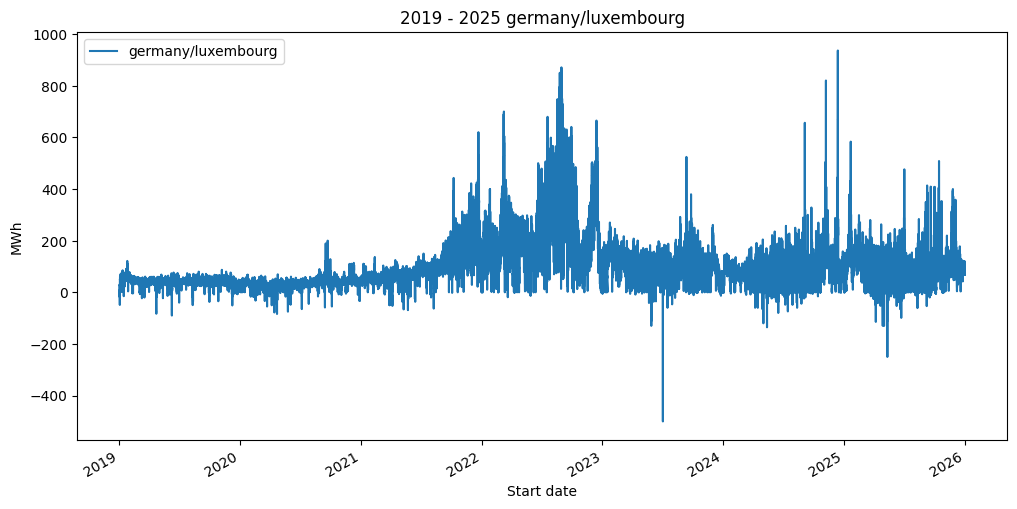

In [10]:
# 设置时间为索引，并排序（必须排序才能用字符串切片日期范围）
df_plot = df.set_index('Start date').sort_index()
# 绘制 germany/luxembourg 的电价
df_plot.loc['2019-01-01':'2025-12-31', ['germany/luxembourg']].plot(figsize=(12, 6))
plt.title("2019 - 2025 germany/luxembourg")
plt.ylabel("MWh")
plt.show()

In [12]:
minus_prices = df['germany/luxembourg']<0
print(f"负电价出现的次数: {minus_prices.sum()}")    

负电价出现的次数: 8322


负电价总次数: 8322

按年份分布：
year
2019     844
2020    1192
2021     556
2022     276
2023    1204
2024    1828
2025    2299
2026     123
Name: count, dtype: int64

按月份分布：
month
1      350
2      463
3      774
4      884
5     1356
6     1084
7      744
8      724
9      572
10     571
11      92
12     708
Name: count, dtype: int64

按小时分布：
hour
0      166
1      231
2      280
3      306
4      300
5      224
6      189
7      166
8      138
9      212
10     413
11     633
12     882
13    1135
14    1130
15     928
16     585
17     200
18      45
19      16
20      29
21      34
22      20
23      60
Name: count, dtype: int64

按星期分布：
weekday
Monday        934
Tuesday       728
Wednesday     549
Thursday      441
Friday        578
Saturday     1711
Sunday       3381
Name: count, dtype: int64


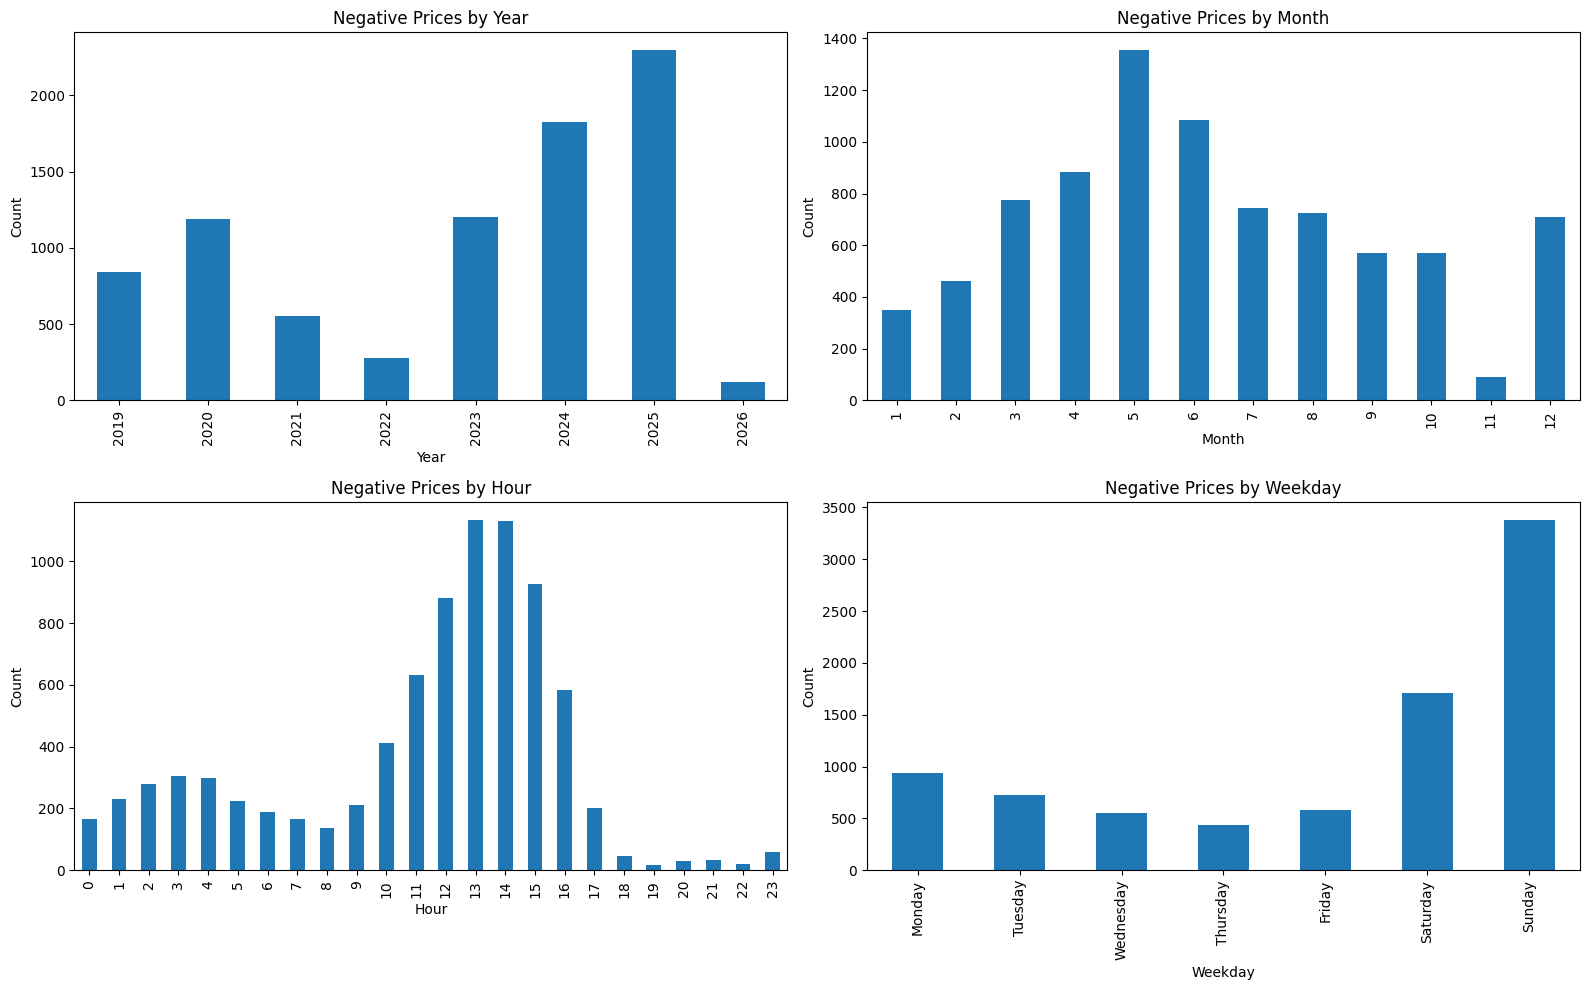

In [14]:
# 负电价出现时段分布分析
negative_df = df.loc[minus_prices, ['Start date', 'germany/luxembourg']].copy()

negative_df['year'] = negative_df['Start date'].dt.year
negative_df['month'] = negative_df['Start date'].dt.month
negative_df['hour'] = negative_df['Start date'].dt.hour
negative_df['weekday'] = negative_df['Start date'].dt.day_name()

year_counts = negative_df['year'].value_counts().sort_index()
month_counts = negative_df['month'].value_counts().sort_index()
hour_counts = negative_df['hour'].value_counts().sort_index()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = negative_df['weekday'].value_counts().reindex(weekday_order)

print("负电价总次数:", len(negative_df))
print("\n按年份分布：")
print(year_counts)
print("\n按月份分布：")
print(month_counts)
print("\n按小时分布：")
print(hour_counts)
print("\n按星期分布：")
print(weekday_counts)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

year_counts.plot(kind='bar', ax=axes[0, 0], title='Negative Prices by Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Count')

month_counts.plot(kind='bar', ax=axes[0, 1], title='Negative Prices by Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Count')

hour_counts.plot(kind='bar', ax=axes[1, 0], title='Negative Prices by Hour')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Count')

weekday_counts.plot(kind='bar', ax=axes[1, 1], title='Negative Prices by Weekday')
axes[1, 1].set_xlabel('Weekday')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()